In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import time
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics.pairwise import haversine_distances
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor

## 1. Carga de datos, análisis y limpieza.

In [14]:
# NODE 1 (LWAT01)
train_rssi_aux   = pd.read_csv("LWAT02_trnrss.csv", header=None)
train_coords_aux = pd.read_csv("LWAT02_trncrd.csv", header=None)

test_rssi_aux    = pd.read_csv("LWAT02_tstrss.csv", header=None)
test_coords_aux  = pd.read_csv("LWAT02_tstcrd.csv", header=None)

In [15]:
# Unimos
X = pd.concat([train_rssi_aux, test_rssi_aux], ignore_index=True)
y = pd.concat([train_coords_aux, test_coords_aux], ignore_index=True)

# Separamos aleatoriamente manteniendo porcentaje
train_rssi, test_rssi, train_coords, test_coords = train_test_split(
    X,
    y,
    test_size=0.1967,
    random_state=42,
    shuffle=True
)

In [16]:
print("Muestras Train en 2018:", train_rssi.shape[0])
print("Muestras Test en 2018:", test_rssi.shape[0])
total = train_rssi.shape[0] + test_rssi.shape[0]
print("Total de muestras en la campaña de 2018:", total)
print("\n")
print("Número de gateways en 2018:", train_rssi.shape[1])
print("\n")
train_pct = train_rssi.shape[0] / total * 100
test_pct = test_rssi.shape[0] / total * 100
print(f"Porcentaje Train 2018: {train_pct:.2f}%")
print(f"Porcentaje Test 2018: {test_pct:.2f}%")

Muestras Train en 2018: 104773
Muestras Test en 2018: 25656
Total de muestras en la campaña de 2018: 130429


Número de gateways en 2018: 72


Porcentaje Train 2018: 80.33%
Porcentaje Test 2018: 19.67%


In [17]:
# Preparamos las variables de entrada y salida
X_train = train_rssi.fillna(-200)
X_test  = test_rssi.fillna(-200)
y_train = train_coords.iloc[:, :2]
y_test  = test_coords.iloc[:, :2]

# ignorar -200
min_rssi = X_train[X_train != -200].min().min()
tau = min_rssi - 1

# Tau lo usaremos para los valores señal 0 (No recibida o no consta)
print("min_rssi:", min_rssi)
print("tau:", tau)

min_rssi: -127.0
tau: -128.0


In [18]:
# Procesaremso los datos de tres formas distintas segun lo explican en el articulo

def preprocess_rssi_base(X, tau):
    X = X.copy()
    # Sustituir -200 por tau (no señal)
    X[X == -200] = tau
    # Positivos
    X = X - tau
    # Normalization [0,1]
    X = X / X.max().max()
    return X

def preprocess_rssi_exponential(X, tau, alpha=60):
    X = X.copy()
    # Sustituir -200 por tau (no señal)
    X[X == -200] = tau
    # Positivos
    X = X - tau
    # Exponencial
    X = np.exp(X / alpha) / np.exp(-tau / alpha)
    return X

def preprocess_rssi_power(X, tau, beta=1.1):
    X = X.copy()
    # Sustituir -200 por tau (no señal)
    X[X == -200] = tau
    # Positivos
    X = X - tau
    # Power
    X = (X ** beta) / ((-tau) ** beta)
    return X

In [19]:
X_train_base = preprocess_rssi_base(X_train, tau)
X_test_base  = preprocess_rssi_base(X_test, tau)

X_train_pow = preprocess_rssi_power(X_train, tau)
X_test_pow  = preprocess_rssi_power(X_test, tau)

X_train_exp = preprocess_rssi_exponential(X_train, tau)
X_test_exp  = preprocess_rssi_exponential(X_test, tau)

In [20]:
scaler_y = StandardScaler()
y_train_scaled = pd.DataFrame(
    scaler_y.fit_transform(y_train),
    index=y_train.index,
    columns=y_train.columns)

## KNN

In [21]:
param_grid = {'n_neighbors': list(range(15, 22))}
knn = KNeighborsRegressor(metric='braycurtis')

grid_knn = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)

start = time.time()
grid_knn.fit(X_train_base, y_train_scaled)
# Guardamos los resultados en un dataframe
result_grid = pd.DataFrame(grid_knn.cv_results_)
end = time.time()
best_k = grid_knn.best_params_['n_neighbors']
print(f"Valor óptimo de k: {best_k}")
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Valor óptimo de k: 21
Tiempo total: 590.22 segundos


In [22]:
knn_opt = KNeighborsRegressor(n_neighbors=best_k, metric='braycurtis')
knn_opt.fit(X_train_base, y_train_scaled)

,n_neighbors,21
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'braycurtis'
,metric_params,None
,n_jobs,None


In [23]:
start = time.time()

# TRAIN

y_train_pred_scaled = knn_opt.predict(X_train_base)
y_train_pred_knn = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_knn[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"KNN Mean: {dist_train.mean():.2f}")
print(f"KNN Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = knn_opt.predict(X_test_base)
y_test_pred_knn = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_knn[:, [1, 0]])

dist_test_knn2 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('TEST:')
print(f"KNN Mean: {dist_test_knn2.mean():.2f}")
print(f"KNN Median: {np.median(dist_test_knn2):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
KNN Mean: 315.13
KNN Median: 195.21
TEST:
KNN Mean: 333.72
KNN Median: 212.57
Tiempo total: 158.89 segundos


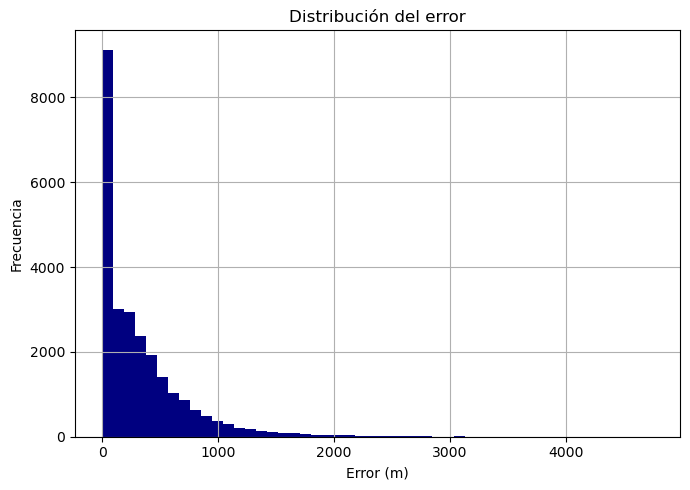

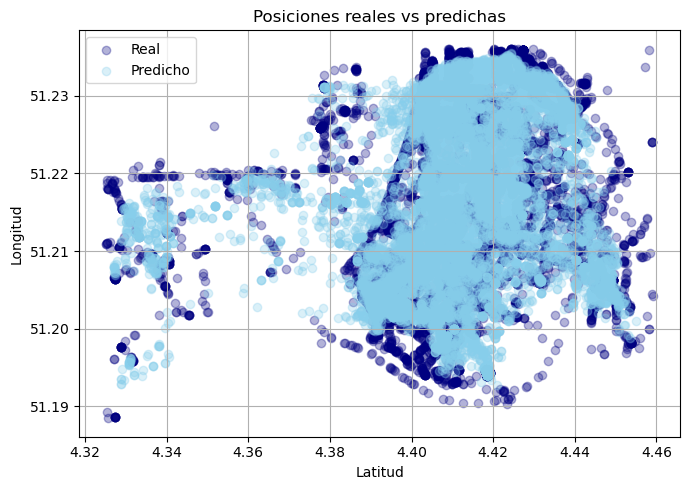

In [24]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_knn2, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## RF

In [13]:
start = time.time()
# Definimos el modelo
rfr = RandomForestRegressor(random_state=42, n_jobs=-1)
# Guardamos en un diccionario los valores que probaremos
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [30, 40, 50],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [1, 2, 5]
}
# Utilizamos GridSearchCV con validación cruzada (cross validation) con 3 particiones estratificadas
grid_rfr = GridSearchCV(
    rfr,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Entrenamos GridSearchCV y guardamos los resultados en un DataFrame
grid_rfr.fit(X_train_pow, y_train_scaled)

best_params = grid_rfr.best_params_
print(best_params)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
{'max_depth': 40, 'min_samples_leaf': 1, 'min_samples_split': 15, 'n_estimators': 150}
Tiempo total: 812.45 segundos


In [14]:
start = time.time()

# Almacenamos la mejor combinación de parámetros
best_n_estimators = best_params['n_estimators']
best_max_depth = best_params['max_depth']
best_min_samples_split = best_params['min_samples_split']
best_min_samples_leaf = best_params['min_samples_leaf']

# Entrenamos con la mejor combinación de parámetros
rfr_opt = RandomForestRegressor(n_estimators=best_n_estimators,
                                max_depth=best_max_depth,
                                min_samples_split=best_min_samples_split,
                                min_samples_leaf=best_min_samples_leaf,
                                random_state=42,
                                n_jobs=-1)
rfr_opt.fit(X_train_pow, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 7.00 segundos


In [15]:
start = time.time()

# TRAIN

y_train_pred_scaled = rfr_opt.predict(X_train_pow)
y_train_pred_rfr = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_rfr[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"RandomForest Mean: {dist_train.mean():.2f}")
print(f"RandomForest Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = rfr_opt.predict(X_test_pow)
y_test_pred_rfr = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_rfr[:, [1, 0]])

dist_test_rfr2 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"RandomForest Mean: {dist_test_rfr2.mean():.2f}")
print(f"RandomForest Median: {np.median(dist_test_rfr2):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
RandomForest Mean: 275.80
RandomForest Median: 163.17

TEST:
RandomForest Mean: 326.60
RandomForest Median: 201.42
Tiempo total: 23.48 segundos


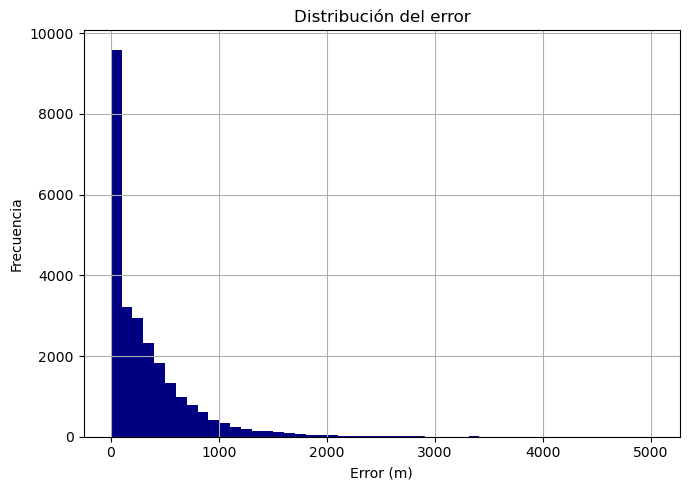

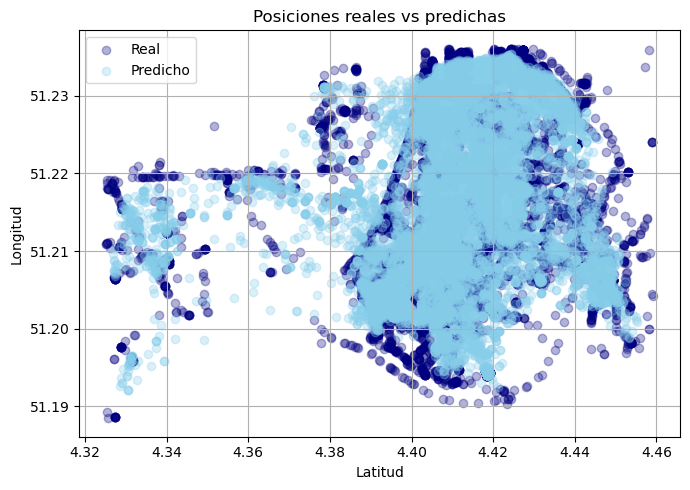

In [16]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_rfr2, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## ET

In [17]:
start = time.time()
# Definimos el modelo
etr = ExtraTreesRegressor(random_state=42, n_jobs=-1)
# Guardamos en un diccionario los valores que probaremos
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [30, 40, 50],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [1, 2, 5]
}
# Utilizamos GridSearchCV con validación cruzada (cross validation) con 3 particiones estratificadas
grid_etr = GridSearchCV(
    etr,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Entrenamos GridSearchCV y guardamos los resultados en un DataFrame
grid_etr.fit(X_train_base, y_train_scaled)
#grid_etr.fit(X_small, y_small)
best_params = grid_etr.best_params_
print(best_params)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
{'max_depth': 40, 'min_samples_leaf': 1, 'min_samples_split': 20, 'n_estimators': 150}
Tiempo total: 979.52 segundos


In [18]:
start = time.time()

# Almacenamos la mejor combinación de parámetros
best_n_estimators = best_params['n_estimators']
best_max_depth = best_params['max_depth']
best_min_samples_split = best_params['min_samples_split']
best_min_samples_leaf = best_params['min_samples_leaf']

# Entrenamos con la mejor combinación de parámetros
etr_opt = ExtraTreesRegressor(n_estimators=best_n_estimators,
                              max_depth=best_max_depth,
                              min_samples_split=best_min_samples_split,
                              min_samples_leaf=best_min_samples_leaf,
                              random_state=42,
                              n_jobs=-1)
etr_opt.fit(X_train_base, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 7.23 segundos


In [19]:
start = time.time()

# TRAIN

y_train_pred_scaled = etr_opt.predict(X_train_base)
y_train_pred_etr = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_etr[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"ExtraTrees Mean: {dist_train.mean():.2f}")
print(f"ExtraTrees Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = etr_opt.predict(X_test_base)
y_test_pred_etr = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_etr[:, [1, 0]])

dist_test_etr1 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"ExtraTrees Mean: {dist_test_etr1.mean():.2f}")
print(f"ExtraTrees Median: {np.median(dist_test_etr1):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
ExtraTrees Mean: 273.29
ExtraTrees Median: 162.10

TEST:
ExtraTrees Mean: 330.93
ExtraTrees Median: 211.52
Tiempo total: 23.20 segundos


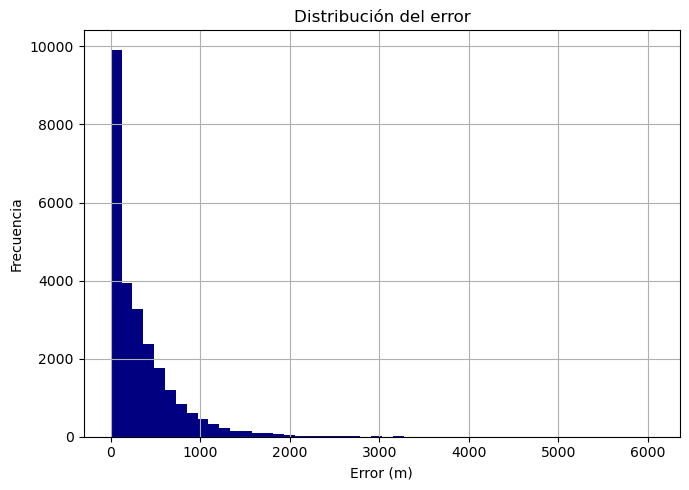

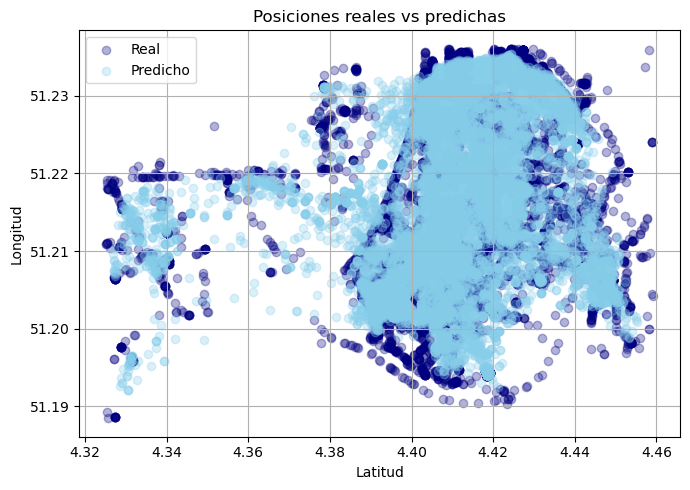

In [20]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_etr1, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## GB

In [21]:
start = time.time()
# Definimos el modelo
gbr = MultiOutputRegressor(GradientBoostingRegressor(random_state=42))
# Guardamos en un diccionario los valores que probaremos
param_grid = {
    'estimator__n_estimators': [100, 150, 200],
    'estimator__learning_rate': [0.05, 0.7],
    'estimator__max_depth': [9, 11, 13],
}
# Utilizamos GridSearchCV con validación cruzada (cross validation) con 3 particiones estratificadas
grid_gbr = GridSearchCV(
    gbr,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Entrenamos GridSearchCV y guardamos los resultados en un DataFrame
grid_gbr.fit(X_train_base, y_train_scaled)

best_params = grid_gbr.best_params_
print(best_params)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
{'estimator__learning_rate': 0.05, 'estimator__max_depth': 11, 'estimator__n_estimators': 200}
Tiempo total: 673.54 segundos


In [22]:
start = time.time()

# Almacenamos la mejor combinación de parámetros
best_n_estimators = best_params['estimator__n_estimators']
best_learning_rate = best_params['estimator__learning_rate']
best_max_depth = best_params['estimator__max_depth']

# Entrenamos con la mejor combinación de parámetros
gbr_opt = MultiOutputRegressor(GradientBoostingRegressor(
    n_estimators=best_n_estimators,
    learning_rate=best_learning_rate,
    max_depth=best_max_depth,
    random_state=42))
gbr_opt.fit(X_train_base, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 137.80 segundos


In [23]:
start = time.time()

# TRAIN

y_train_pred_scaled = gbr_opt.predict(X_train_base)
y_train_pred_gbr = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_gbr[:, [1, 0]])

dist_train = np.array([
    haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000
#dist_train = haversine_distances(y_true_train_rad, y_pred_train_rad).diagonal() * 6371000

print('TRAIN:')
print(f"GradientBoosting Mean: {dist_train.mean():.2f}")
print(f"GradientBoosting Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = gbr_opt.predict(X_test_base)
y_test_pred_gbr = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_gbr[:, [1, 0]])

dist_test_gbr1 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"GradientBoosting Mean: {dist_test_gbr1.mean():.2f}")
print(f"GradientBoosting Median: {np.median(dist_test_gbr1):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
GradientBoosting Mean: 285.56
GradientBoosting Median: 171.06

TEST:
GradientBoosting Mean: 341.43
GradientBoosting Median: 224.49
Tiempo total: 24.55 segundos


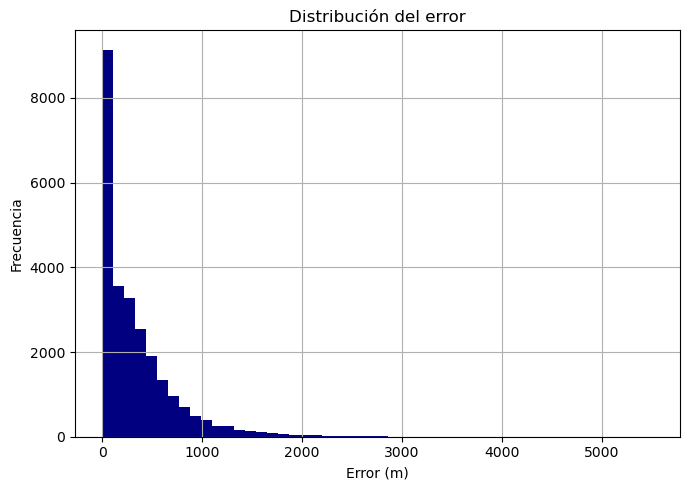

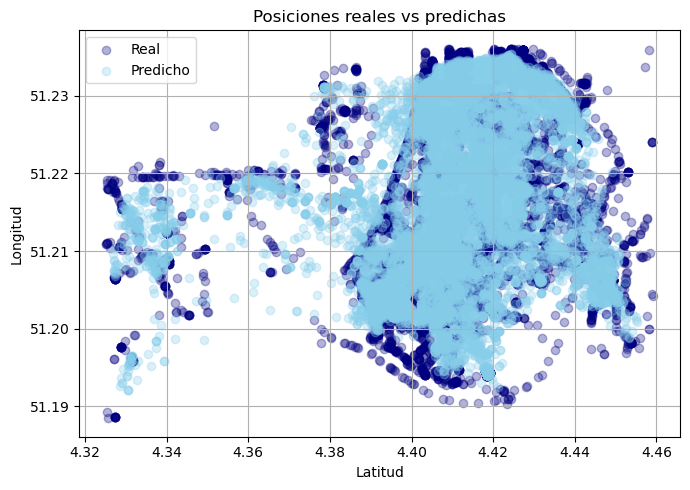

In [24]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_gbr1, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## MLP

In [25]:
# Definimos el modelo
mlp = MLPRegressor(
    hidden_layer_sizes=(256,128,64),
    #activation='relu',
    #solver='adam',
    #alpha=0.0001,
    batch_size=256,
    max_iter=300,
    early_stopping=True,
    random_state=42
)

In [26]:
start = time.time()

# Entrenamos el modelo
mlp.fit(X_train_base, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 35.11 segundos


In [27]:
start = time.time()

# TRAIN

y_train_pred_scaled = mlp.predict(X_train_base)
y_train_pred_mlp = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_mlp[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"MLP Mean: {dist_train.mean():.2f}")
print(f"MLP Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = mlp.predict(X_test_base)
y_test_pred_mlp = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_mlp[:, [1, 0]])

dist_test_mlp1 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"MLP Mean: {dist_test_mlp1.mean():.2f}")
print(f"MLP Median: {np.median(dist_test_mlp1):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
MLP Mean: 327.65
MLP Median: 222.98

TEST:
MLP Mean: 336.75
MLP Median: 228.48
Tiempo total: 23.14 segundos


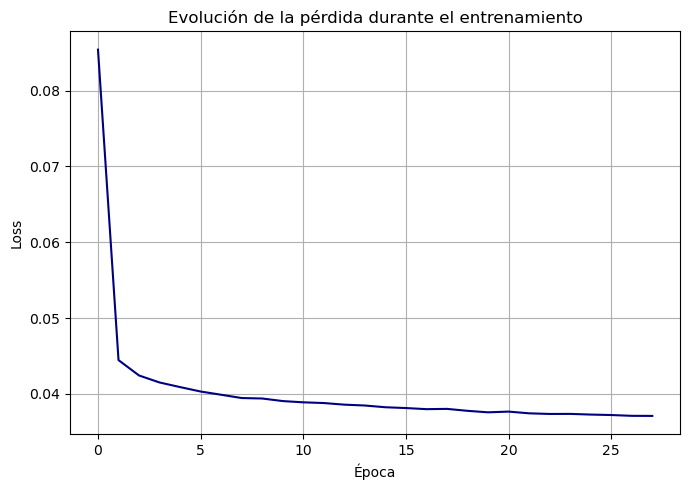

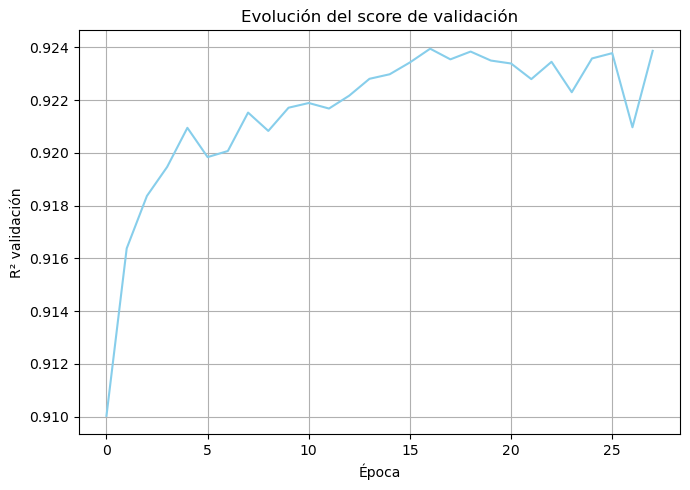

In [28]:
# CURVA DE PÉRDIDA

plt.figure(figsize=(7,5))
plt.plot(mlp.loss_curve_, color="navy")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# VALIDACIÓN

plt.figure(figsize=(7,5))
plt.plot(mlp.validation_scores_, color="skyblue")
plt.title("Evolución del score de validación")
plt.xlabel("Época")
plt.ylabel("R² validación")
plt.grid(True)
plt.tight_layout()
plt.show()

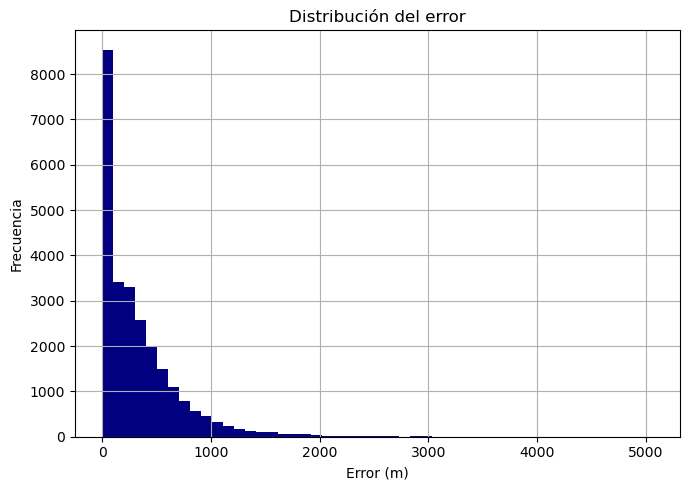

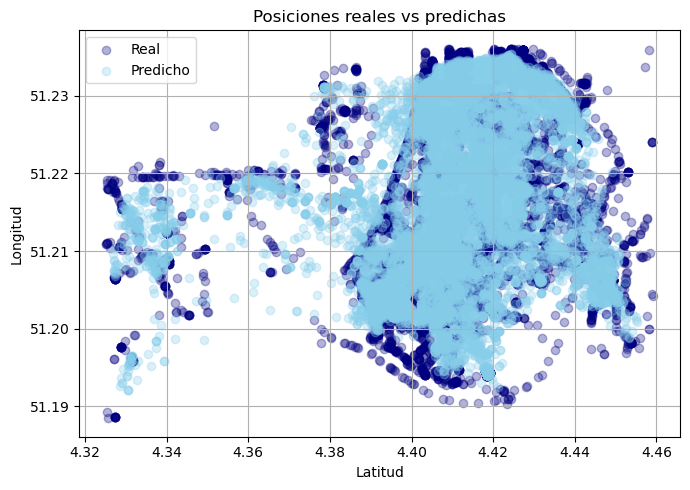

In [29]:
# HISTOGRAMA (distribución de los errores)

plt.figure(figsize=(7,5))
plt.hist(dist_test_mlp1, bins=50, color="navy")
plt.title("Distribución del error")
plt.xlabel("Error (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

# SCATTER (Calidad espacial de las predicciones)

plt.figure(figsize=(7,5))
plt.scatter(y_test.iloc[:,0], y_test.iloc[:,1], alpha=0.3, label="Real", color="navy")
plt.scatter(y_test_pred_knn[:,0], y_test_pred_knn[:,1], alpha=0.3, label="Predicho", color="skyblue")
plt.title("Posiciones reales vs predichas")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()